<a href="https://colab.research.google.com/github/sumitkharayat/Machine-learning-work/blob/main/Multiclass%20Classification%20models%20for%20studens%20performance%20level%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 8 - Implement Multiclass Classification models for students
Performance Level analysis and perform comparative analysis.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Applied ML lab/Exp-5,6,7,8 Data and Question-20260301/multiclass_classification_dataset_500_samples.csv")
df.head()

,Study_Hours,Attendance_Percentage,Assignment_Score,Internal_Marks,Participation,Internet_Access,Previous_Grade,Performance_Level
0,22.48,84.26,86.79,76.68,Medium,Yes,B,1
1,19.31,94.09,81.10,56.73,Low,Yes,B,1
2,23.24,61.01,70.72,52.73,Medium,Yes,A,0
3,27.62,80.63,62.24,64.95,Low,Yes,C,0
4,18.83,68.49,78.38,62.45,High,Yes,B,0


Preprocess

In [3]:
def preprocess_data(df):
    df = df.dropna()
 # Encode categorical columns
    le = LabelEncoder()
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = le.fit_transform(df[col])

    # Separate features and target
    X = df.drop('Performance_Level', axis=1)
    y = df['Performance_Level']

    return X, y

Feature scaling

In [4]:
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test


Spliting

In [5]:
def split_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=42)


Model

In [6]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='multinomial'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}


Train andd evaluate

In [7]:
# Ensure all necessary variables are defined before training
# Preprocess data
X, y = preprocess_data(df)

# Split data (X_train and X_test will be the unscaled versions)
X_train, X_test, y_train, y_test = split_data(X, y)

# Scale features (creating the scaled versions)
X_train_scaled, X_test_scaled = scale_features(X_train, X_test)

results = {}

for name, model in models.items():

    # Models that NEED scaling
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Models that DON'T need scaling
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("\n", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))




 Decision Tree
Accuracy: 0.87
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        49
           1       0.89      0.84      0.86        49
           2       0.50      1.00      0.67         2

    accuracy                           0.87       100
   macro avg       0.76      0.91      0.81       100
weighted avg       0.88      0.87      0.87       100


 Random Forest
Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        49
           1       0.92      0.90      0.91        49
           2       0.00      0.00      0.00         2

    accuracy                           0.91       100
   macro avg       0.61      0.62      0.61       100
weighted avg       0.89      0.91      0.90       100


 Logistic Regression
Accuracy: 0.97
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        49
           1       0.94      1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/l


 XGBoost
Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        49
           1       0.92      0.98      0.95        49
           2       0.00      0.00      0.00         2

    accuracy                           0.95       100
   macro avg       0.63      0.65      0.64       100
weighted avg       0.93      0.95      0.94       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
# BEST MODEL

best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# Predict again using correct data
if best_model_name in ["Logistic Regression", "KNN"]:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)


Best Model: Logistic Regression


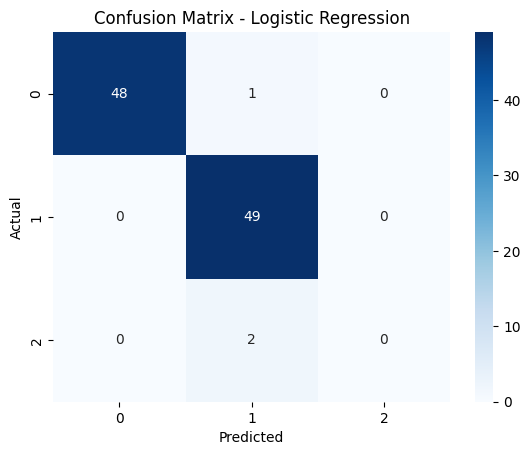

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - " + best_model_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipykernel_13154/2535377621.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')


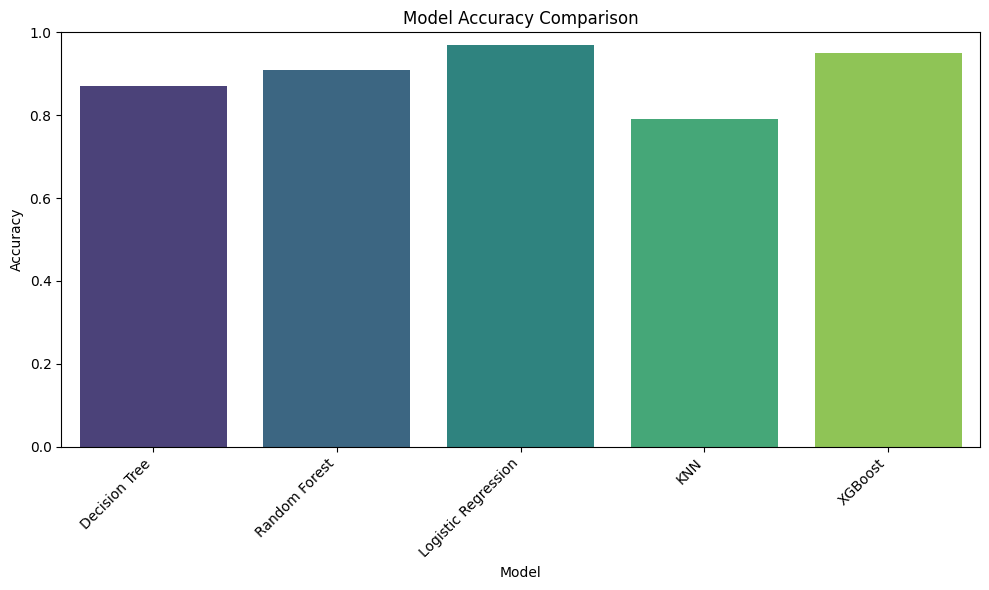

In [10]:
model_names = list(results.keys())
accuracy_scores = list(results.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The scale from 0.0 to 1.0 on the bar chart represents the accuracy score of each model. A higher value on this scale indicates better model performance, with 1.0 being a perfect accuracy (100% correct predictions) and 0.0 being no correct predictions.